<a href="https://colab.research.google.com/github/ViddaD48/1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0/blob/main/data_preproccesing/01_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Clone your repo into Colab
!git clone https://github.com/ViddaD48/1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0
%cd 1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0

# Copy or save your notebook there
!cp /content/01_data_preprocessing.ipynb .

# Commit and push
!git add 01_data_preprocessing.ipynb
!git commit -m "Added preprocessing notebook"
!git push origin main


Cloning into '1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: '1D---CNN-model-development-for-MIT-BIH-Arrhythmia-Database-v1.0.0'
/content
cp: cannot stat '/content/01_data_preprocessing.ipynb': No such file or directory
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 109.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


The `wfdb` library allows you to read various PhysioBank formatted files. Here's how you can read `.dat` and `.hea` files (which contain signal data and header information, respectively) for a given record. Annotations (`.atr` files) can also be read similarly.

In [ ]:
import wfdb

# --- Example: Reading a record from a local path ---
# Replace 'your_record_name' with the actual name of your record (e.g., '100' for MIT-BIH).
# Make sure the .dat, .hea, and .atr files are in the 'path_to_your_files' directory.
# For example, if you have '100.dat', '100.hea', '100.atr', your_record_name would be '100'.

# IMPORTANT: Change this to the actual path where your files are located.
path_to_your_files = '/content/' # Example: if your files are directly in the Colab environment
record_name = '100' # Example: '100' - Changed from 'your_record_name'

try:
    # Read the signal and metadata (.dat and .hea files)
    record = wfdb.rdrecord(path_to_your_files + record_name)
    print(f"Successfully read record: {record_name}")

    # Display some information about the record
    print("\nRecord Information:")
    print(record.__dict__)

    # You can access the signal data:
    # signals = record.p_signal # This will be a numpy array of the signals
    # print(f"\nSignal shape: {signals.shape}")

    # Read annotations (.atr file)
    annotation = wfdb.rdann(path_to_your_files + record_name, extension='atr')
    print(f"\nSuccessfully read annotations for record: {record_name}")

    # Display some information about the annotations
    print("\nAnnotation Information:")
    print(f"Sample locations: {annotation.sample[:5]}...") # First 5 sample locations
    print(f"Symbols: {annotation.symbol[:5]}...") # First 5 annotation symbols

except FileNotFoundError:
    print(f"Error: One or more files for record '{record_name}' not found in '{path_to_your_files}'.")
    print("Please ensure 'your_record_name.dat', 'your_record_name.hea', and 'your_record_name.atr' exist at the specified path.")
except Exception as e:
    print(f"An error occurred: {e}")


# --- Example: Reading a record directly from a PhysioBank database (e.g., MIT-BIH Arrhythmia Database) ---
# This requires an internet connection.
# record, fields = wfdb.rdsamp('mitdb/100', pn_dir='mitdb') # Reads signal and header
# annotation = wfdb.rdann('mitdb/100', 'atr', pn_dir='mitdb') # Reads annotations

# You can then display the records:
# display(record.__dict__)
# display(annotation.__dict__)


Successfully read record: 100

Record Information:
{'record_name': '100', 'n_sig': 2, 'fs': 360, 'counter_freq': None, 'base_counter': None, 'sig_len': 650000, 'base_time': None, 'base_date': None, 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'], 'sig_name': ['MLII', 'V5'], 'p_signal': array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       ...,
       [-0.675, -0.365],
       [-0.765, -0.335],
       [-1.28 ,  0.   ]]), 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['100.dat', '100.dat'], 'fmt': ['212', '212'], 'samps_per_frame': [1, 1], 'skew': [None, None], 'byte_offset': [None, None], 'adc_gain': [200.0, 200.0], 'baseline': [1024, 1024], 'units': ['mV', 'mV'], 'adc_res': [11, 11], 'adc_zero': [1024, 1024], 'init_value': [995, 1011], 'checksum': [-22131, 20052], 'block_size': [0, 0]}

Successfully read annotations for record: 100

Annotation Information:
Sample locations: [ 18  77 370 662 946]...
Symbols: ['+', 'N', 'N', 'N', 

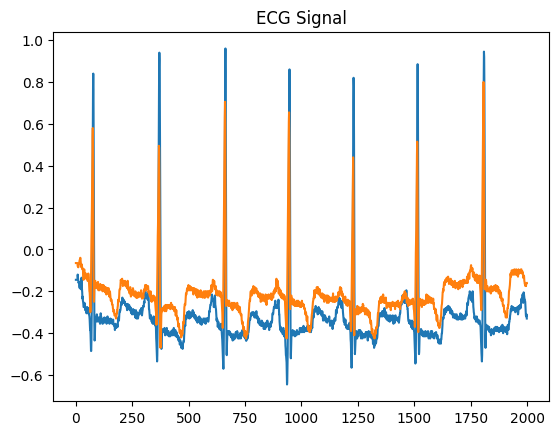

In [ ]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100')
annotation = wfdb.rdann('100', 'atr')

signal = record.p_signal
fs = record.fs

plt.plot(signal[:2000])
plt.title("ECG Signal")
plt.show()

Signal shape: (650000, 2)
Annotation symbols: {'V', 'A', '+', 'N'}
First 10 R-peak positions: [  18   77  370  662  946 1231 1515 1809 2044 2402]


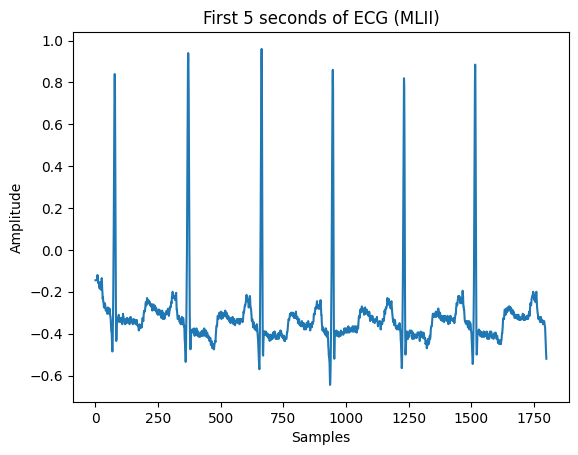

In [ ]:
import wfdb
import matplotlib.pyplot as plt

# Load the record (signal)
record = wfdb.rdrecord('100')  # path to your .dat/.hea files

# Load the annotations (labels)
annotation = wfdb.rdann('100', 'atr')

# Access signals
signals = record.p_signal  # shape: (samples, channels)

# Print info
print("Signal shape:", signals.shape)
print("Annotation symbols:", set(annotation.symbol))
print("First 10 R-peak positions:", annotation.sample[:10])

# Plot first 5 seconds of channel 0 (MLII)
plt.plot(signals[:5*360, 0])  # 360 samples per second
plt.title("First 5 seconds of ECG (MLII)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [ ]:
import numpy as np

fs = record.fs  # sampling frequency, usually 360 Hz
window = int(0.6 * fs)  # 0.6 seconds around each R-peak
half_window = window // 2

segments = []
labels = []

for r_peak, label in zip(annotation.sample, annotation.symbol):
    start = r_peak - half_window
    end = r_peak + half_window
    if start >= 0 and end <= signals.shape[0]:
        segment = signals[start:end, 0]  # take channel 0 (MLII)
        segments.append(segment)
        labels.append(label)

segments = np.array(segments)
labels = np.array(labels)

print("Segment shape:", segments.shape)  # (num_beats, window_length)


Segment shape: (2271, 216)
